# Résultats : quatre figures

Ce notebook **lit** les résultats écrits par les scripts (`results/block_ci.json` des deux versions, avec et
sans TTL) ; il ne relance aucun modèle et ne calcule aucune métrique. Chaque chiffre tracé est un point
estimé et un intervalle à 95 % par rééchantillonnage de blocs de temps de 10 minutes (1 000 réplications,
graine 42 ; README §3.6), le même que dans les tables du README.

Prérequis : avoir exécuté la chaîne de la section 7 du README (`make all`). Pour réexécuter ce notebook :
`make notebook`.

Codage commun aux figures : **bleu = sans TTL** (résultat principal), **orange = avec TTL** (mesure du
raccourci) ; barres d'erreur = intervalle par blocs.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from prepare import load_config  # noqa: E402

CONFIGS = {"sans": ROOT / "config_sans_ttl.toml", "avec": ROOT / "config.toml"}
cfg = {k: load_config(p) for k, p in CONFIGS.items()}
CI = {k: json.loads((ROOT / c["data"]["processed_dir"] / "results" / "block_ci.json").read_text())
      for k, c in cfg.items()}
BUDGETS = [str(b) for b in cfg["avec"]["evaluation"]["fpr_budgets"]]   # 1 %, 0,1 %, 0,01 %
REF = str(cfg["avec"]["evaluation"]["reference_fpr"])                  # 0,1 %
REMOVED = cfg["avec"]["families"]["removed"]                            # Exploits, Reconnaissance
# Étiquettes du test (identiques dans les deux versions) : prévalence et effectif par famille.
TEST = pd.read_parquet(ROOT / cfg["sans"]["data"]["processed_dir"] / "test.parquet", columns=["family", "label"])
PREV = TEST["label"].mean()
N_TEST = TEST.loc[TEST["label"] == 1, "family"].value_counts()

MODELS = [("isolation_forest", "Isolation\nForest"), ("autoencoder_moyen", "Autoenc.\nmoyen"),
          ("autoencoder_petit", "Autoenc.\npetit"), ("supervised_A", "Supervisé\nA"),
          ("supervised_B", "Supervisé\nB"), ("supervised_C", "Supervisé\nC")]
VERSIONS = [("sans", "sans TTL (principal)"), ("avec", "avec TTL (raccourci)")]
COLOR = {"sans": "#2a78d6", "avec": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e2dd"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False, "axes.axisbelow": True,
})


def entry(version: str, model: str, key: str) -> tuple[float, float, float]:
    """(point, borne basse, borne haute) d'une entrée de block_ci.json."""
    e = CI[version]["models"][model][key]
    return e["point"], e["lo"], e["hi"]


def pct(b: str) -> str:
    """Budget '0.001' -> '0,1 %'."""
    return f"{100 * float(b):g} %".replace(".", ",")


def bars(ax, x, version, values, width, scale=100.0, **kw):
    """Barres d'un même groupe de valeurs (point, lo, hi), avec l'intervalle par blocs en barre d'erreur."""
    pts = np.array([v[0] for v in values]) * scale
    err = np.array([[v[0] - v[1], v[2] - v[0]] for v in values]).T * scale
    ax.bar(x, pts, width, color=COLOR.get(version, version), edgecolor="white", linewidth=1.5,
           yerr=err, error_kw={"ecolor": INK, "elinewidth": 0.9, "capsize": 2.5}, **kw)
    return pts

print("Résultats lus :", {k: f'{c["data"]["processed_dir"]}/results' for k, c in cfg.items()})
print(f"Test : {len(TEST)} lignes, {int(TEST['label'].sum())} attaques, prévalence {100 * PREV:.3f} %")
print("Blocs :", CI["sans"]["block_minutes"], "min,", CI["sans"]["n_blocks"], "blocs,",
      CI["sans"]["n_boot"], "réplications, graine", CI["sans"]["seed"])

Résultats lus : {'sans': 'data/processed_sans_ttl/results', 'avec': 'data/processed/results'}
Test : 1023196 lignes, 14278 attaques, prévalence 1.395 %
Blocs : 10 min, 76 blocs, 1000 réplications, graine 42


## Figure 1 — Que perd le supervisé sur une famille qu'il n'a jamais vue ?

Rappel des trois conditions supervisées sur les deux familles retirées de C (Exploits, Reconnaissance).
A : toutes les familles ; B : même volume d'attaques que C, toutes les familles ; C : Exploits et
Reconnaissance retirés. **L'écart B − C est l'effet de la famille absente à volume égal.**

Rappel *lu au même taux* de faux positifs sur le test (non déployable, sert à comparer à taux égal,
README §3.5), aux deux budgets stricts : à 1 % le rappel de toutes les conditions est saturé (README §5).
Les écarts appariés B − C et leurs intervalles sont dans les tableaux 9 et 15 du README ; les barres
d'erreur ci-dessous sont des intervalles marginaux, non appariés.

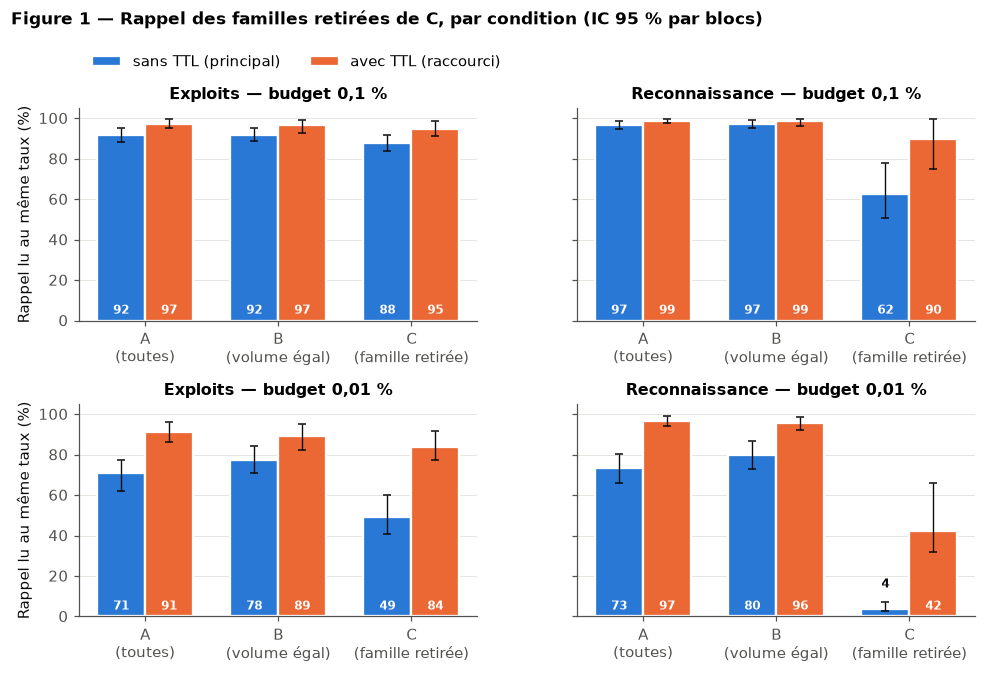

In [2]:
fams = REMOVED
budgets = [b for b in BUDGETS if float(b) < 0.01]
fig, axes = plt.subplots(len(budgets), len(fams), figsize=(9, 6.2), sharey=True)
conds = ["A", "B", "C"]
x, w = np.arange(len(conds)), 0.36
for i, b in enumerate(budgets):
    for j, fam in enumerate(fams):
        ax = axes[i, j]
        for k, (v, lab) in enumerate(VERSIONS):
            vals = [entry(v, f"supervised_{c}", f"recall_matched|{b}|{fam}") for c in conds]
            pts = bars(ax, x + (k - 0.5) * w, v, vals, w, label=lab)
            for xx, p in zip(x + (k - 0.5) * w, pts):
                inside = p >= 12  # sur une barre courte, la valeur va au-dessus, en encre
                ax.text(xx, 2 if inside else p + 9, f"{p:.0f}", ha="center", va="bottom", fontsize=8,
                        color="white" if inside else INK, fontweight="bold")
        ax.set_xticks(x, ["A\n(toutes)", "B\n(volume égal)", "C\n(famille retirée)"])
        ax.set_ylim(0, 105)
        ax.set_title(f"{fam} — budget {pct(b)}")
        if j == 0:
            ax.set_ylabel("Rappel lu au même taux (%)")
axes[0, 0].legend(loc="lower left", bbox_to_anchor=(0, 1.12), ncol=2)
fig.suptitle("Figure 1 — Rappel des familles retirées de C, par condition (IC 95 % par blocs)", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
plt.show()

## Figure 2 — Un modèle qui n'a jamais vu d'attaque en détecte-t-il ?

Les modèles au budget de référence (0,1 % de faux positifs) : trois modèles non supervisés (Isolation
Forest, deux autoencodeurs) et le supervisé dans ses trois conditions. À gauche l'AUC-PR, indépendante du
seuil (trait gris : prévalence des attaques au test, valeur d'un score aléatoire) ; à droite le rappel lu au
même taux de 0,1 %. Le rappel *au seuil calibré*, déployable, dépend de la calibration : voir figure 3 et
tableau 3 du README.

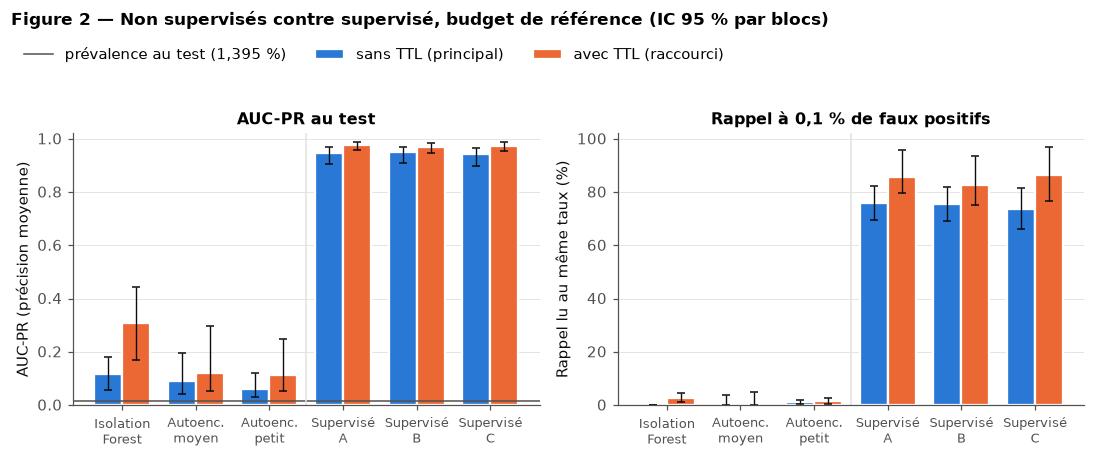

In [3]:
prev = PREV
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
x, w = np.arange(len(MODELS)), 0.38
for k, (v, lab) in enumerate(VERSIONS):
    bars(axes[0], x + (k - 0.5) * w, v, [entry(v, m, "ap") for m, _ in MODELS], w, scale=1.0, label=lab)
    bars(axes[1], x + (k - 0.5) * w, v, [entry(v, m, f"recall_matched|{REF}|all") for m, _ in MODELS], w)
axes[0].axhline(prev, color=MUTED, linewidth=1,
                label=f"prévalence au test ({100 * prev:.3f} %)".replace(".", ","))
axes[0].set(ylim=(0, 1.02), ylabel="AUC-PR (précision moyenne)", title="AUC-PR au test")
axes[1].set(ylim=(0, 102), ylabel="Rappel lu au même taux (%)", title=f"Rappel à {pct(REF)} de faux positifs")
for ax in axes:
    ax.set_xticks(x, [lab for _, lab in MODELS], fontsize=8.5)
    ax.axvline(2.5, color=GRID, linewidth=1)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper left", bbox_to_anchor=(0.01, 0.93), ncol=3)
fig.suptitle("Figure 2 — Non supervisés contre supervisé, budget de référence (IC 95 % par blocs)", x=0.01,
             ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()

## Figure 3 — Le taux de faux positifs visé est-il celui qu'on obtient ?

Pour chaque modèle, le seuil est calibré sur les scores hors échantillon des normaux du jour
d'entraînement (5 blocs de temps, README §3.5) pour viser un budget ; on trace le taux de faux positifs
*observé* sur les normaux du test, en échelle logarithmique. Sur la diagonale, le taux visé est tenu ;
au-dessus, le modèle déclenche plus de fausses alertes que prévu. Le trait gris horizontal marque un seul faux
positif sur les normaux du test : la résolution de la mesure. Une borne basse d'intervalle nulle (aucun faux
positif dans certaines réplications) est tracée jusqu'au bord inférieur.

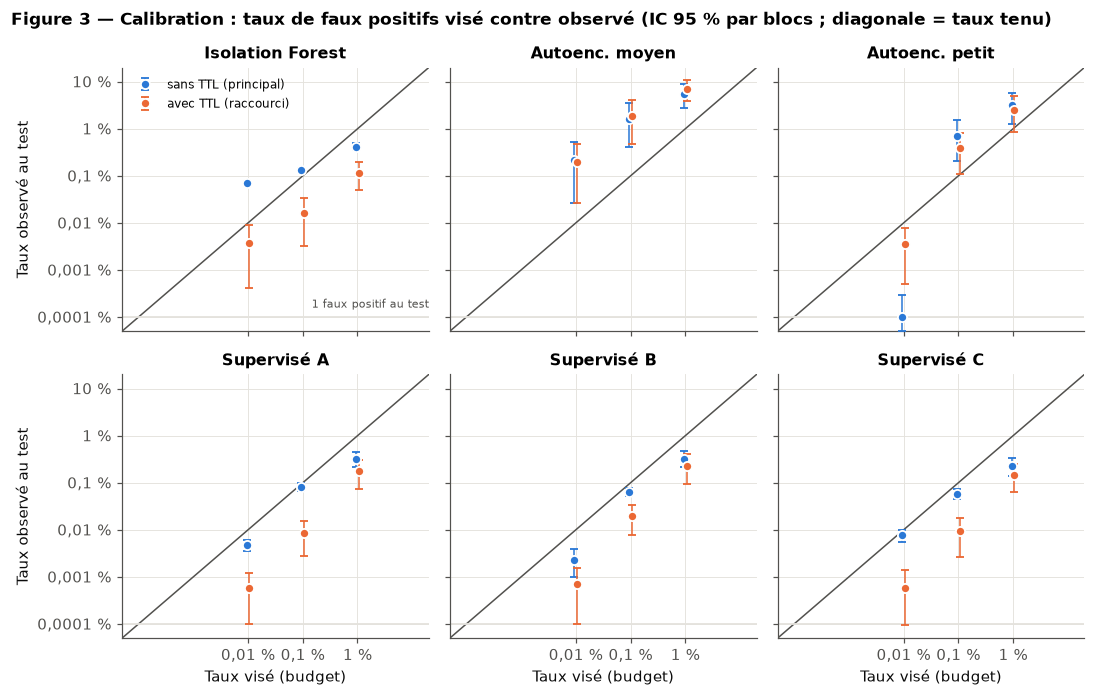

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4), sharex=True, sharey=True)
target = np.array([float(b) for b in BUDGETS]) * 100
lim = (5e-5, 20)  # en % ; le plus petit taux observé non nul est d'un faux positif au test
one_fp = 100 / (TEST["label"] == 0).sum()
for ax, (m, lab) in zip(axes.flat, MODELS):
    ax.plot(lim, lim, color=MUTED, linewidth=1, zorder=1)
    ax.axhline(one_fp, color=GRID, linewidth=1.2, zorder=1)
    for k, (v, vl) in enumerate(VERSIONS):
        vals = np.array([entry(v, m, f"fpr_cal|{b}") for b in BUDGETS]) * 100
        vals[:, 1] = np.maximum(vals[:, 1], lim[0])  # borne basse nulle : tracée jusqu'au bord
        shift = 1.06 if k else 1 / 1.06  # décalage horizontal pour que les barres d'erreur ne se superposent pas
        ax.errorbar(target * shift, vals[:, 0], yerr=[vals[:, 0] - vals[:, 1], vals[:, 2] - vals[:, 0]],
                    fmt="o", ms=6, color=COLOR[v], mec="white", mew=1.2, elinewidth=1, capsize=2.5,
                    label=vl, zorder=3)
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, title=lab.replace("\n", " "))
    ax.grid(True, which="major", axis="both")
    ax.set_xticks(target, [pct(b) for b in BUDGETS])
    ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10], ["0,0001 %", "0,001 %", "0,01 %", "0,1 %", "1 %", "10 %"])
    ax.minorticks_off()
for ax in axes[1]:
    ax.set_xlabel("Taux visé (budget)")
for ax in axes[:, 0]:
    ax.set_ylabel("Taux observé au test")
axes[0, 0].text(lim[1], one_fp * 1.4, "1 faux positif au test", ha="right", va="bottom", fontsize=7.5, color=MUTED)
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Figure 3 — Calibration : taux de faux positifs visé contre observé (IC 95 % par blocs ; "
             "diagonale = taux tenu)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## Figure 4 — La perte de C est-elle propre aux familles retirées ?

Rappel par famille des trois conditions supervisées, **sans TTL**, lu au même taux, aux deux budgets
stricts. Les familles retirées de C sont sur fond grisé. Entre parenthèses, le nombre d'attaques de la
famille au test : pour Analysis, Backdoors, Shellcode et Worms, les intervalles par blocs couvrent une
grande partie de [0 ; 100] et ces rappels ne sont pas interprétables individuellement (README §6).

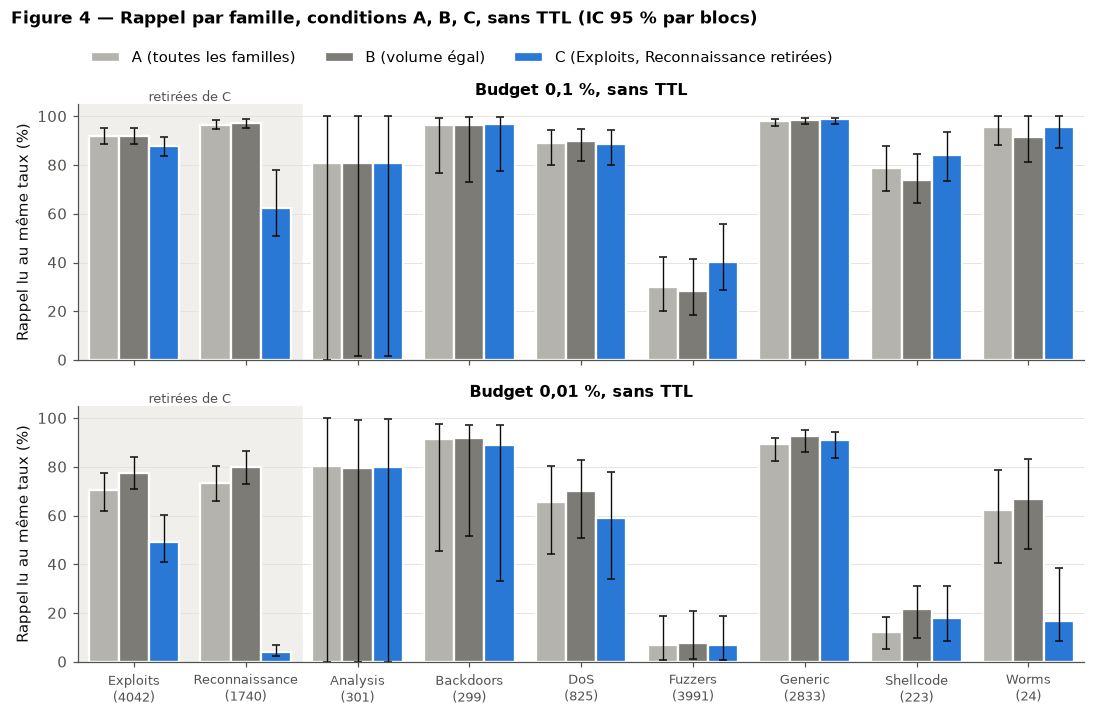

In [5]:
n_test = N_TEST
fams = REMOVED + sorted(f for f in N_TEST.index if f not in REMOVED)
cond_color = {"A": "#b5b3ad", "B": "#7d7b76", "C": COLOR["sans"]}  # C mis en avant, A et B en gris
budgets = [b for b in BUDGETS if float(b) < 0.01]
fig, axes = plt.subplots(len(budgets), 1, figsize=(10, 6.6), sharex=True)
x, w = np.arange(len(fams)), 0.27
for ax, b in zip(axes, budgets):
    ax.axvspan(-0.5, len(REMOVED) - 0.5, color="#f0efec", zorder=0)
    for k, c in enumerate(["A", "B", "C"]):
        vals = [entry("sans", f"supervised_{c}", f"recall_matched|{b}|{f}") for f in fams]
        bars(ax, x + (k - 1) * w, cond_color[c], vals, w,
             label={"A": "A (toutes les familles)", "B": "B (volume égal)", "C": "C (Exploits, Reconnaissance retirées)"}[c])
    ax.set(ylim=(0, 105), ylabel="Rappel lu au même taux (%)", title=f"Budget {pct(b)}, sans TTL")
    ax.set_xlim(-0.5, len(fams) - 0.5)
for ax in axes:
    ax.text(0.5, 1.0, "retirées de C", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=8.5, color=MUTED)
axes[-1].set_xticks(x, [f"{f}\n({n_test[f]})" for f in fams], fontsize=8.5)
axes[0].legend(loc="lower left", bbox_to_anchor=(0, 1.1), ncol=3)
fig.suptitle("Figure 4 — Rappel par famille, conditions A, B, C, sans TTL (IC 95 % par blocs)", x=0.01,
             ha="left", fontweight="bold")
fig.tight_layout()
plt.show()